In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("KNMI_cleaned_mvp.csv")
df["date"] = pd.to_datetime(df["date"])

df.head()

,station_id,date,wind_direction_deg,vector_avg_wind_speed_ms,avg_wind_speed_ms
0,225,2017-01-01,212.0,8.1,9.5
1,225,2017-01-02,346.0,7.8,8.5
2,225,2017-01-03,277.0,11.3,11.4
3,225,2017-01-04,331.0,12.6,13.1
4,225,2017-01-05,59.0,3.9,5.4


In [13]:
station_names = {
    225: "IJmuiden",
    242: "Vlieland Vliehors",
    269: "Lelystad Airport",
    310: "Vlissingen",
    330: "Hoek van Holland"
}

df["station_name"] = df["station_id"].map(station_names)

df.head()

,station_id,date,wind_direction_deg,vector_avg_wind_speed_ms,avg_wind_speed_ms,station_name
0,225,2017-01-01,212.0,8.1,9.5,IJmuiden
1,225,2017-01-02,346.0,7.8,8.5,IJmuiden
2,225,2017-01-03,277.0,11.3,11.4,IJmuiden
3,225,2017-01-04,331.0,12.6,13.1,IJmuiden
4,225,2017-01-05,59.0,3.9,5.4,IJmuiden


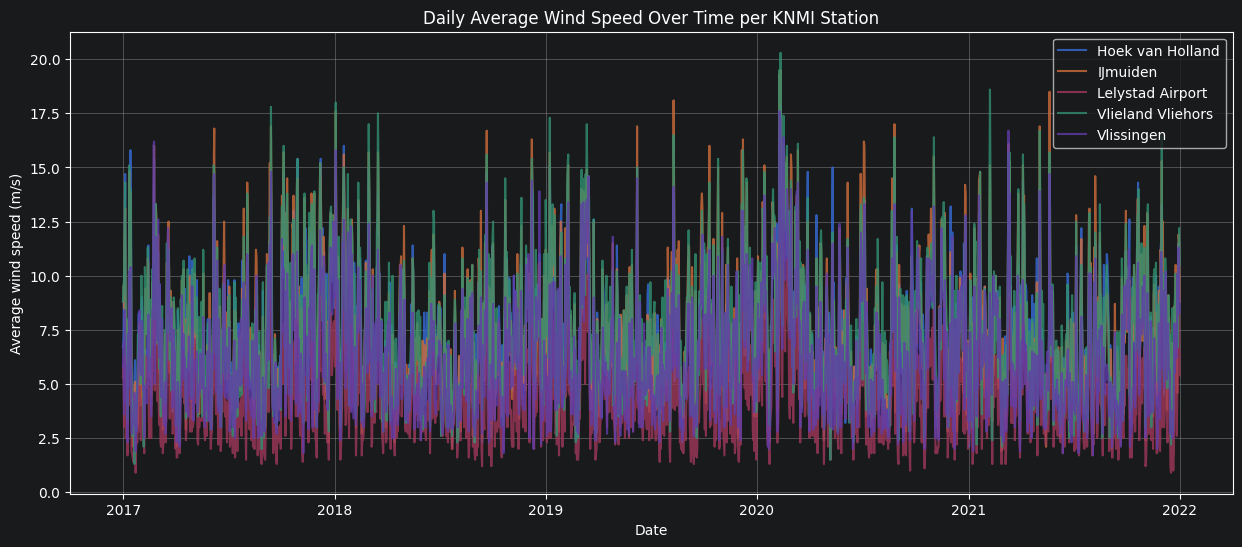

In [14]:
plt.figure(figsize=(15, 6))

for station, station_df in df.groupby("station_name"):
    plt.plot(
        station_df["date"],
        station_df["avg_wind_speed_ms"],
        label=station,
        alpha=0.8
    )

plt.title("Daily Average Wind Speed Over Time per KNMI Station")
plt.xlabel("Date")
plt.ylabel("Average wind speed (m/s)")
plt.legend()
plt.grid(True)
plt.show()

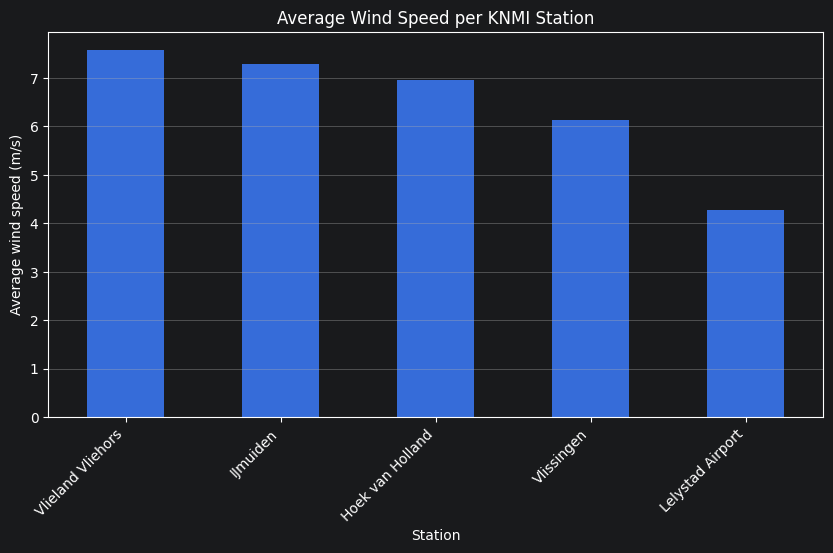

In [15]:
station_avg = (
    df.groupby("station_name")["avg_wind_speed_ms"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
station_avg.plot(kind="bar")

plt.title("Average Wind Speed per KNMI Station")
plt.xlabel("Station")
plt.ylabel("Average wind speed (m/s)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

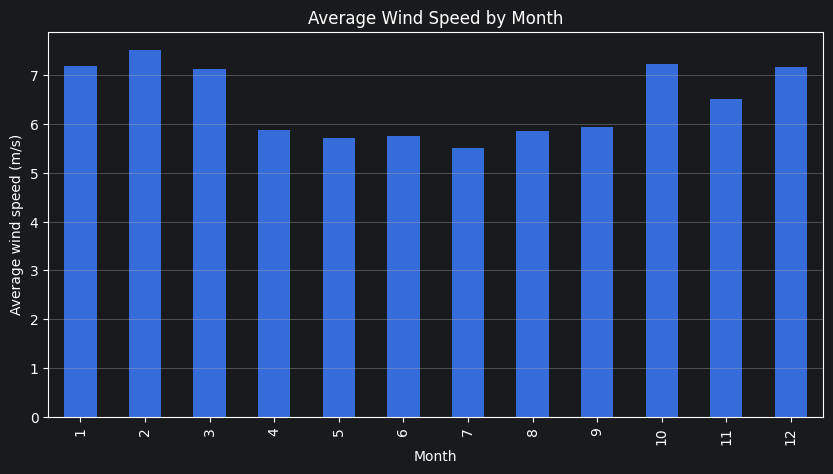

In [16]:
df["month"] = df["date"].dt.month

monthly_avg = df.groupby("month")["avg_wind_speed_ms"].mean()

plt.figure(figsize=(10, 5))
monthly_avg.plot(kind="bar")

plt.title("Average Wind Speed by Month")
plt.xlabel("Month")
plt.ylabel("Average wind speed (m/s)")
plt.grid(axis="y")
plt.show()

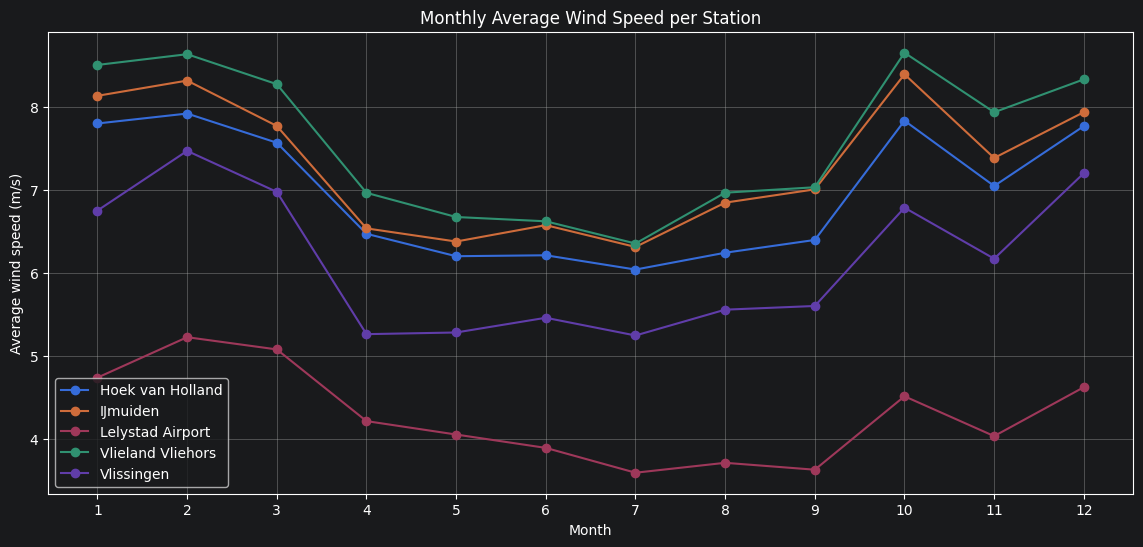

In [17]:
monthly_station = (
    df.groupby(["month", "station_name"])["avg_wind_speed_ms"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))

for station in monthly_station["station_name"].unique():
    station_data = monthly_station[monthly_station["station_name"] == station]
    plt.plot(
        station_data["month"],
        station_data["avg_wind_speed_ms"],
        marker="o",
        label=station
    )

plt.title("Monthly Average Wind Speed per Station")
plt.xlabel("Month")
plt.ylabel("Average wind speed (m/s)")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)
plt.show()

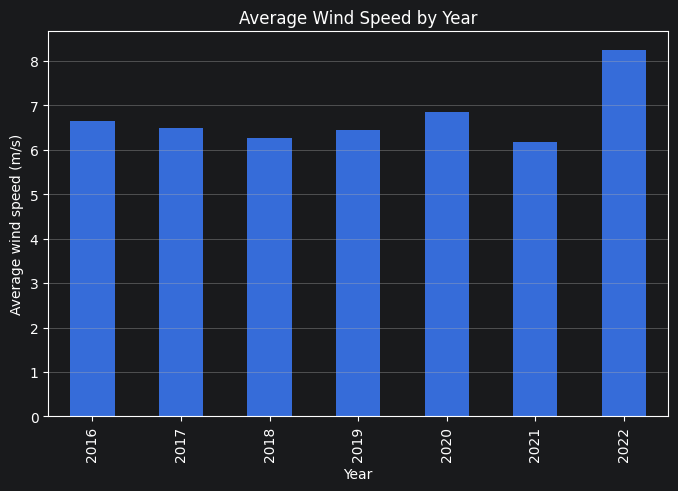

In [18]:
df["year"] = df["date"].dt.year

yearly_avg = df.groupby("year")["avg_wind_speed_ms"].mean()

plt.figure(figsize=(8, 5))
yearly_avg.plot(kind="bar")

plt.title("Average Wind Speed by Year")
plt.xlabel("Year")
plt.ylabel("Average wind speed (m/s)")
plt.grid(axis="y")
plt.show()

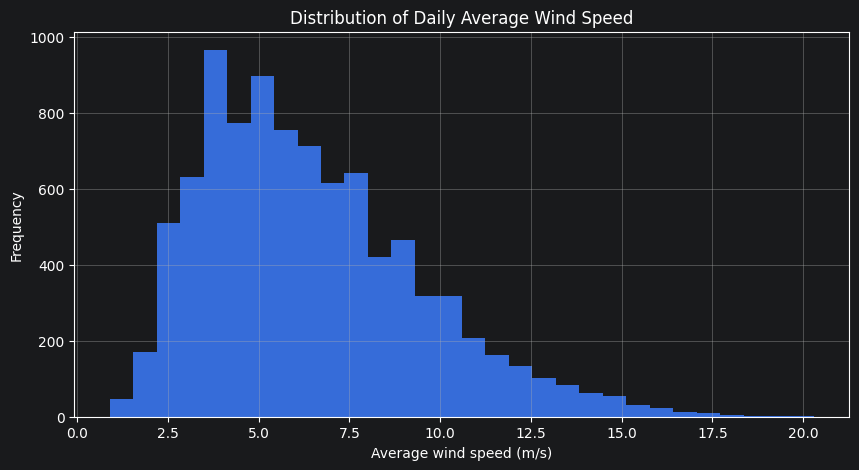

In [19]:
plt.figure(figsize=(10, 5))

plt.hist(df["avg_wind_speed_ms"].dropna(), bins=30)

plt.title("Distribution of Daily Average Wind Speed")
plt.xlabel("Average wind speed (m/s)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

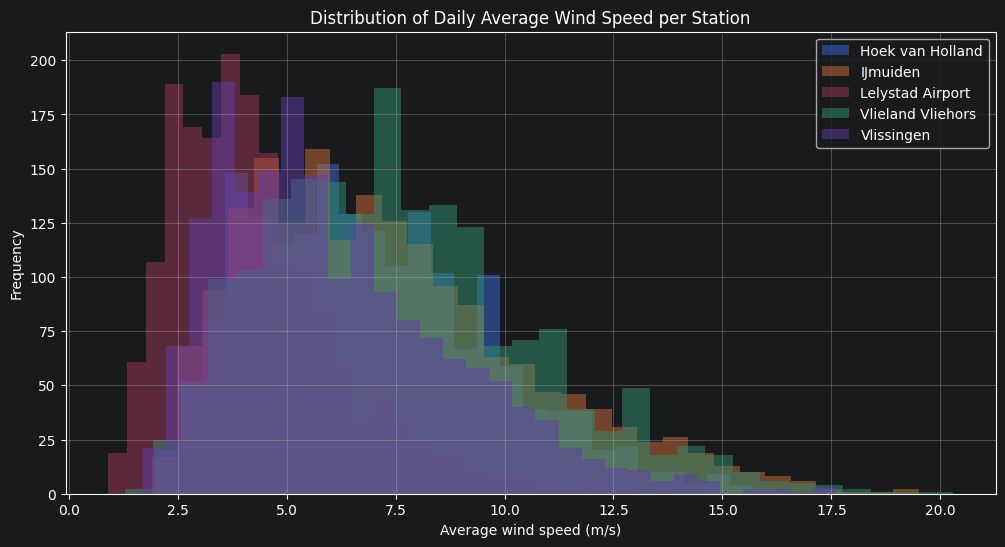

In [20]:
plt.figure(figsize=(12, 6))

for station, station_df in df.groupby("station_name"):
    plt.hist(
        station_df["avg_wind_speed_ms"].dropna(),
        bins=30,
        alpha=0.5,
        label=station
    )

plt.title("Distribution of Daily Average Wind Speed per Station")
plt.xlabel("Average wind speed (m/s)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

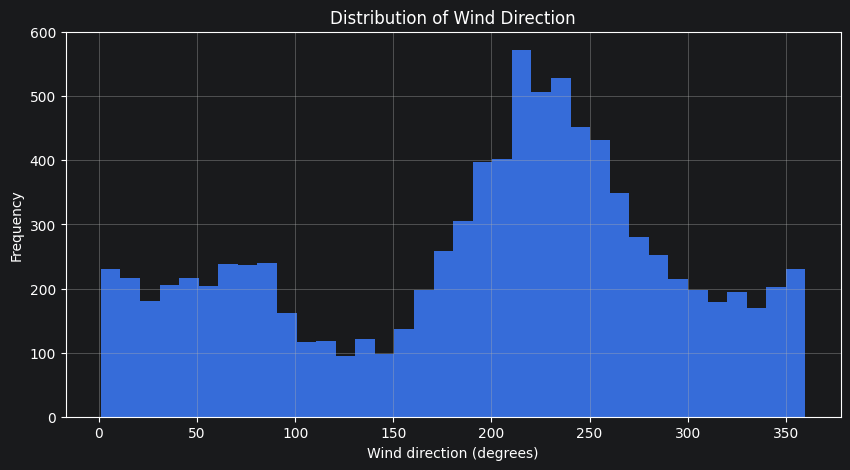

,date,avg_wind_speed_all_stations,vector_avg_wind_speed_all_stations,avg_wind_direction
0,2016-12-31,6.65,6.60,209.5
1,2017-01-01,7.76,6.32,214.8
2,2017-01-02,6.96,6.26,327.0
3,2017-01-03,9.74,9.54,271.2
4,2017-01-04,11.16,10.68,324.8


In [21]:
plt.figure(figsize=(10, 5))

plt.hist(df["wind_direction_deg"].dropna(), bins=36)

plt.title("Distribution of Wind Direction")
plt.xlabel("Wind direction (degrees)")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

daily_weather = df.groupby("date").agg(
    avg_wind_speed_all_stations=("avg_wind_speed_ms", "mean"),
    vector_avg_wind_speed_all_stations=("vector_avg_wind_speed_ms", "mean"),
    avg_wind_direction=("wind_direction_deg", "mean")
).reset_index()

daily_weather.head()

In [22]:
daily_weather = df.groupby("date").agg(
    avg_wind_speed_all_stations=("avg_wind_speed_ms", "mean"),
    vector_avg_wind_speed_all_stations=("vector_avg_wind_speed_ms", "mean"),
    avg_wind_direction=("wind_direction_deg", "mean")
).reset_index()

daily_weather.head()

,date,avg_wind_speed_all_stations,vector_avg_wind_speed_all_stations,avg_wind_direction
0,2016-12-31,6.65,6.60,209.5
1,2017-01-01,7.76,6.32,214.8
2,2017-01-02,6.96,6.26,327.0
3,2017-01-03,9.74,9.54,271.2
4,2017-01-04,11.16,10.68,324.8


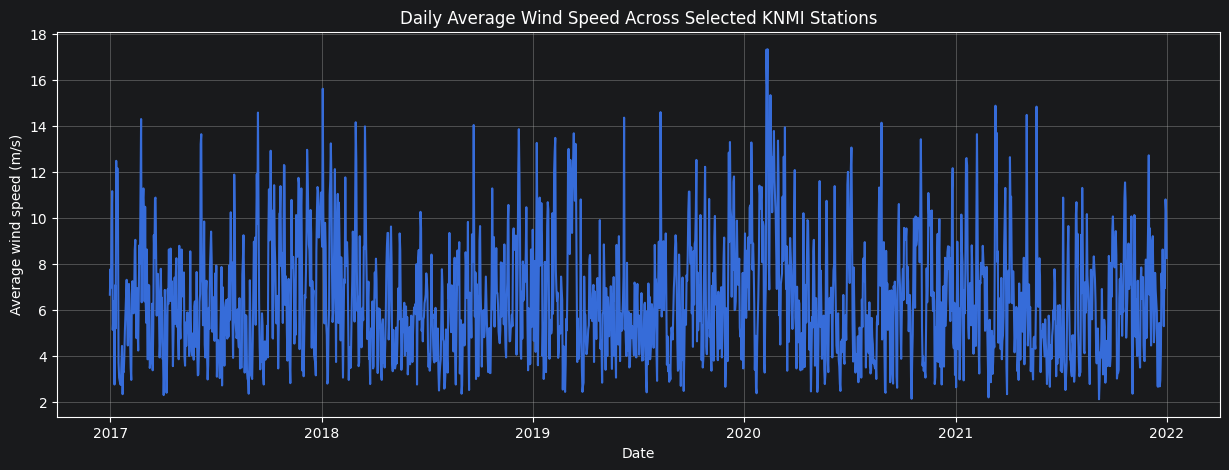

In [23]:
plt.figure(figsize=(15, 5))

plt.plot(
    daily_weather["date"],
    daily_weather["avg_wind_speed_all_stations"]
)

plt.title("Daily Average Wind Speed Across Selected KNMI Stations")
plt.xlabel("Date")
plt.ylabel("Average wind speed (m/s)")
plt.grid(True)
plt.show()

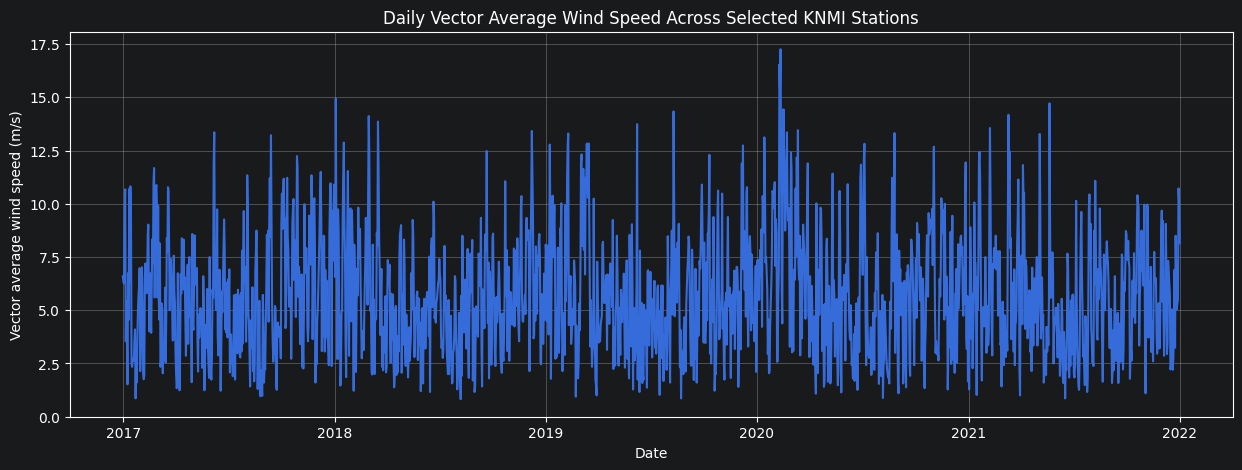

In [24]:
plt.figure(figsize=(15, 5))

plt.plot(
    daily_weather["date"],
    daily_weather["vector_avg_wind_speed_all_stations"]
)

plt.title("Daily Vector Average Wind Speed Across Selected KNMI Stations")
plt.xlabel("Date")
plt.ylabel("Vector average wind speed (m/s)")
plt.grid(True)
plt.show()

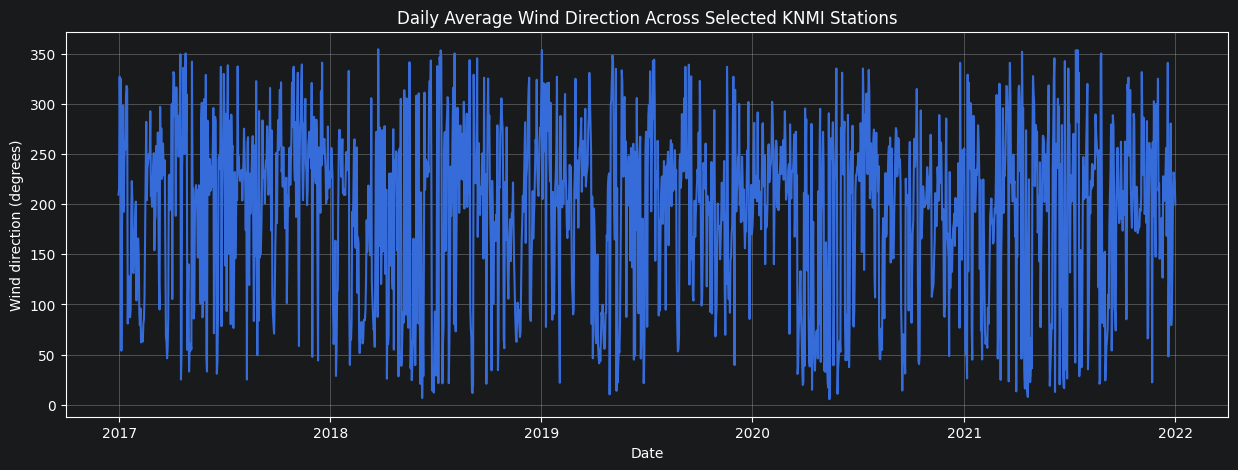

In [25]:
plt.figure(figsize=(15, 5))

plt.plot(
    daily_weather["date"],
    daily_weather["avg_wind_direction"]
)

plt.title("Daily Average Wind Direction Across Selected KNMI Stations")
plt.xlabel("Date")
plt.ylabel("Wind direction (degrees)")
plt.grid(True)
plt.show()

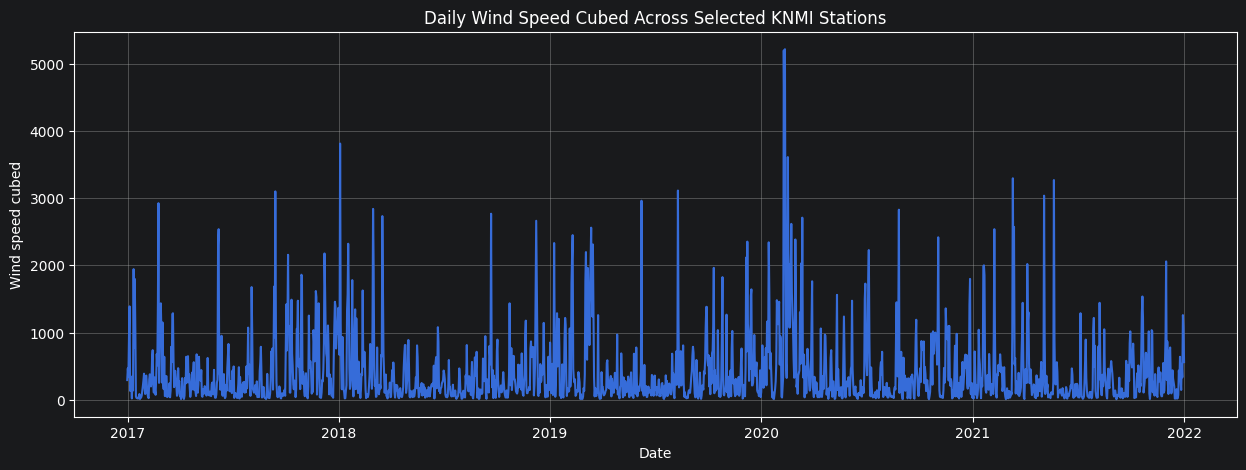

In [26]:
daily_weather["avg_wind_speed_cubed"] = (
    daily_weather["avg_wind_speed_all_stations"] ** 3
)

plt.figure(figsize=(15, 5))

plt.plot(
    daily_weather["date"],
    daily_weather["avg_wind_speed_cubed"]
)

plt.title("Daily Wind Speed Cubed Across Selected KNMI Stations")
plt.xlabel("Date")
plt.ylabel("Wind speed cubed")
plt.grid(True)
plt.show()

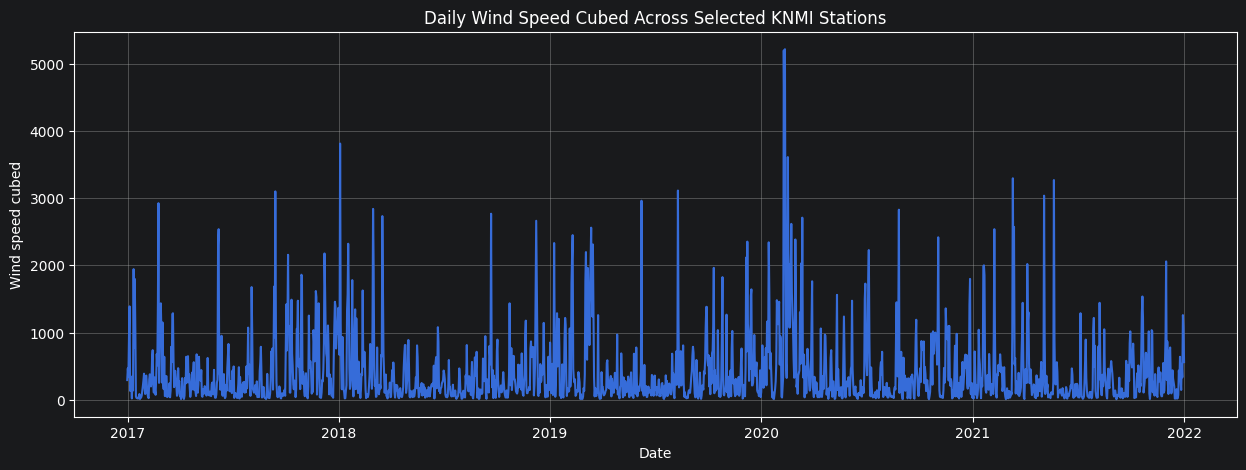

In [27]:
daily_weather["avg_wind_speed_cubed"] = (
    daily_weather["avg_wind_speed_all_stations"] ** 3
)

plt.figure(figsize=(15, 5))

plt.plot(
    daily_weather["date"],
    daily_weather["avg_wind_speed_cubed"]
)

plt.title("Daily Wind Speed Cubed Across Selected KNMI Stations")
plt.xlabel("Date")
plt.ylabel("Wind speed cubed")
plt.grid(True)
plt.show()